In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

# Initializing Spark
spark = SparkSession.builder.appName("Amazon_Appliances_JSONL").getOrCreate()

# Loading the dataset
jsonl_file_path = "/Volumes/workspace/default/datalakes/Appliances.jsonl"
df = spark.read.json(jsonl_file_path)

print("Appliances data (JSONL) loaded successfully!")
print(f"Total number of reviews: {df.count()}")
print("Schema of the dataset:")
df.printSchema()
print("First 5 rows of data:")
df.show(5, truncate=False)

Appliances data (JSONL) loaded successfully!
Total number of reviews: 2128605
Schema of the dataset:
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)

First 5 rows of data:
+----------+------------+------+-----------+------+--------------------------------------------------------------------------------------------------------------------------------------------------

In [0]:
from pyspark.sql.functions import *

df_clean = df \
    .withColumn("helpful_votes", col("helpful_vote").cast("int")) \
    .withColumn("rating", col("rating").cast("float")) \
    .withColumn("text", col("text"))   # Already exists, just ensure it's selected

# Dropping rows missing critical values
df_clean = df_clean.dropna(subset=["rating", "timestamp", "user_id", "parent_asin"])

# Filtering valid ratings between 0.5 and 5.0
df_clean = df_clean.filter((col("rating") >= 1.0.5) & (col("rating") <= 5.0))

# Remove duplicate records
df_clean = df_clean.dropDuplicates(["user_id", "parent_asin", "timestamp"])

df_clean = df_clean \
    .withColumn("review_date", from_unixtime(col("timestamp")/1000).cast("date")) \
    .withColumn("year", year("review_date")) \
    .withColumn("month", month("review_date")) \
    .withColumn("review_length", length(col("text")))

print(f"Rows after cleaning: {df_clean.count()}")
print("Sample cleaned data:")
df_clean.show(5, truncate=False)

Rows after cleaning: 2105948
Sample cleaned data:
+----------+------------+------+-----------+------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+-------------------------------+----------------------------+-----------------+-------------

In [0]:
# Visualization Libraries Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import re
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

/home/spark-e4baf84b-98f7-4e0d-8d57-b1/.ipykernel/2063/command-8101637273737445-2541416261:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating_dist_pd, x="rating", y="count", palette="viridis")


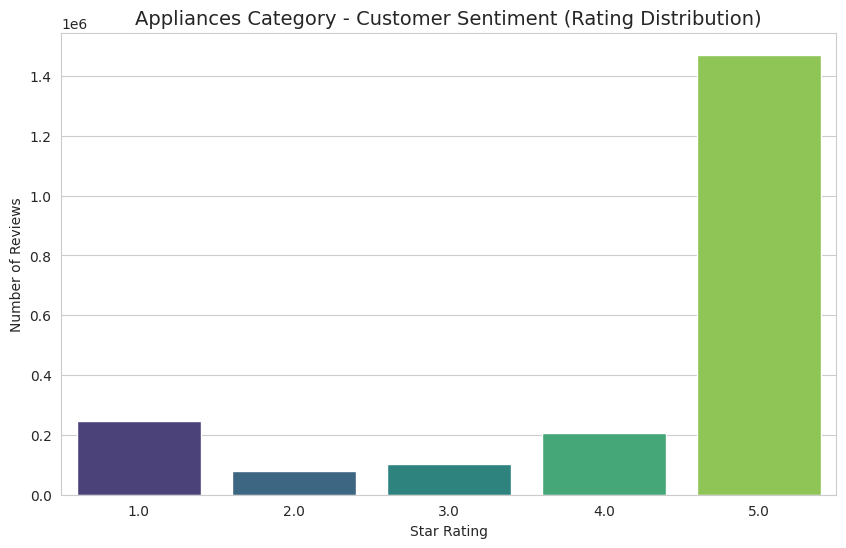

In [0]:
# Aggregating counts
rating_dist = df_clean.groupBy("rating").count().orderBy("rating")
rating_dist_pd = rating_dist.toPandas()

# Generating the bar chart
plt.figure(figsize=(10,6))
sns.barplot(data=rating_dist_pd, x="rating", y="count", palette="viridis")
plt.title("Appliances Category - Customer Sentiment (Rating Distribution)", fontsize=14)
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.savefig("appliances_sentiment_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

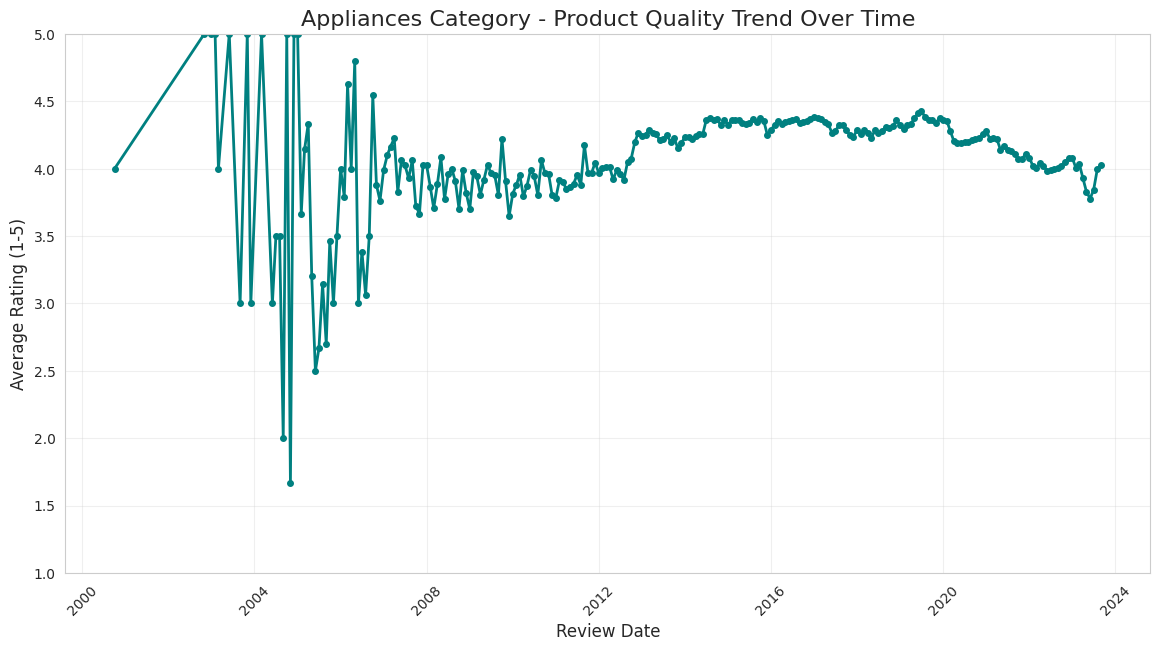

In [0]:
# Aggregating average rating by year/month
trend_data = df_clean.groupBy("year", "month") \
    .agg(avg("rating").alias("avg_rating"), count("*").alias("review_count")) \
    .orderBy("year", "month")

trend_pd = trend_data.toPandas()

if not trend_pd.empty:
    trend_pd['date'] = pd.to_datetime(trend_pd['year'].astype(str) + '-' + trend_pd['month'].astype(str) + '-01')
    trend_pd = trend_pd.sort_values('date')
    
    # Line chart
    plt.figure(figsize=(14,7))
    plt.plot(trend_pd['date'], trend_pd['avg_rating'], marker='o', linestyle='-', linewidth=2, markersize=4, color='teal')
    plt.title("Appliances Category - Product Quality Trend Over Time", fontsize=16)
    plt.xlabel("Review Date", fontsize=12)
    plt.ylabel("Average Rating (1-5)", fontsize=12)
    plt.ylim(1, 5)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.savefig("appliances_quality_trend.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Not enough data for time series plot.")

/home/spark-e4baf84b-98f7-4e0d-8d57-b1/.ipykernel/2063/command-8101637273737447-145934633:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=help_corr_pd, x="rating", y="avg_helpful_votes", palette="coolwarm")


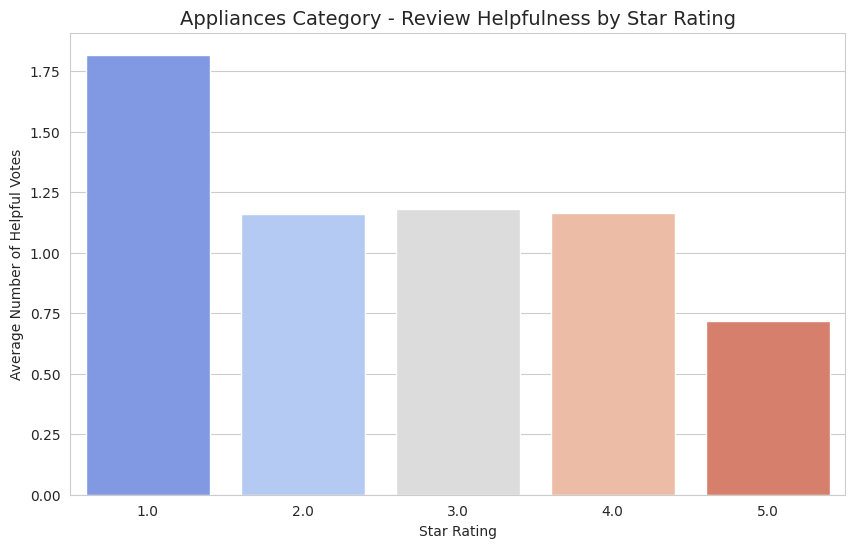

In [0]:
# Correlation between review helpfulness and rating
help_corr_data = df_clean.groupBy("rating") \
    .agg(avg("helpful_votes").alias("avg_helpful_votes"), count("*").alias("review_count")) \
    .orderBy("rating")

help_corr_pd = help_corr_data.toPandas()
plt.figure(figsize=(10,6))
sns.barplot(data=help_corr_pd, x="rating", y="avg_helpful_votes", palette="coolwarm")
plt.title("Appliances Category - Review Helpfulness by Star Rating", fontsize=14)
plt.xlabel("Star Rating")
plt.ylabel("Average Number of Helpful Votes")
plt.savefig("appliances_helpfulness_by_rating.png", dpi=150, bbox_inches='tight')
plt.show()

In [0]:
top_products = df_clean.groupBy("parent_asin") \
    .agg(count("*").alias("review_count"), avg("rating").alias("avg_rating")) \
    .orderBy(col("review_count").desc()) \
    .limit(10)

print("Top 10 Most Reviewed Products:")
top_products.show(truncate=False)

Top 10 Most Reviewed Products:
+-----------+------------+-----------------+
|parent_asin|review_count|avg_rating       |
+-----------+------------+-----------------+
|B0B3DB5HTC |11906       |4.862170334285234|
|B07RNJY499 |11483       |4.161194809718714|
|B07WTXWC32 |8420        |4.500118764845606|
|B08YBGCNHP |7257        |4.325478848008819|
|B000AST3AK |6978        |4.339352249928346|
|B01KJ2FVFW |6081        |4.846900180891301|
|B00UXG4WR8 |5831        |4.075801749271137|
|B000DLB2FI |5675        |3.788898678414097|
|B081KSD3BK |5626        |4.083540703874867|
|B09YC8YCV6 |5357        |3.692178458092216|
+-----------+------------+-----------------+



In [0]:
most_helpful = df_clean.orderBy(col("helpful_votes").desc()) \
    .select("user_id", "parent_asin", "rating", "helpful_votes") \
    .limit(10)

print("Top 10 Most Helpful Reviews:")
most_helpful.show(truncate=False)

Top 10 Most Helpful Reviews:
+----------------------------+-----------+------+-------------+
|user_id                     |parent_asin|rating|helpful_votes|
+----------------------------+-----------+------+-------------+
|AFFKAD3TNCYHYVK4D3QR5KNIPKNQ|B01ALBMIEI |5.0   |5704         |
|AFCESKOAQF2ZVRWBK356RCP2CUWQ|B07YF9SGBW |1.0   |4870         |
|AHQO2B5SYO2A67Y2RFCRVW4UZ55A|B01ALBMIEI |5.0   |4637         |
|AHZKXB5ZUOM5N7DO7D2T4KKQYIQQ|B07YF9SGBW |1.0   |3198         |
|AFJ7YTKL27O2N6DYNDKYCDE3SLRA|B0751KDVTP |1.0   |2799         |
|AGJHOMLDW5NDI7PKWWW5NSFVYCAA|B07YF9SGBW |1.0   |2745         |
|AHJS4IB75XT6YLVSXUTXHMGKFRYQ|B00Q4X2FSM |5.0   |2520         |
|AF7PVTKXZD5GV367AN6VCG7W4DPA|B01ALBMIEI |5.0   |2264         |
|AEEY737I2A5JNJHEPSDSWUGRQNAA|B098W5ND23 |5.0   |1865         |
|AGMR67VWWLZH5V7HV2JCVCSEXBBQ|B07B94ZR74 |5.0   |1862         |
+----------------------------+-----------+------+-------------+

